In [62]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set(style='darkgrid', palette='Dark2')

In [63]:
data=pd.read_csv('bank.csv')
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [64]:
data.isnull().sum()


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [65]:
data.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

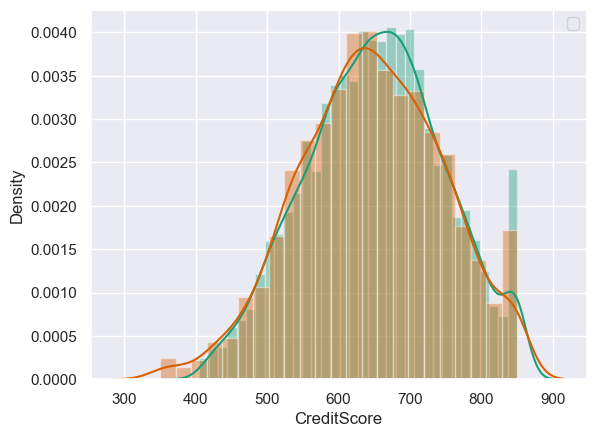

In [66]:
sns.distplot(data.CreditScore[data.Exited==0])
sns.distplot(data.CreditScore[data.Exited==1])
plt.legend()

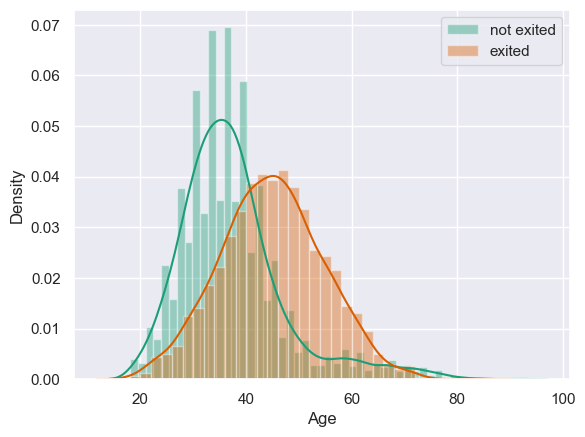

In [67]:
sns.distplot(data.Age[data.Exited==0],label='not exited')
sns.distplot(data.Age[data.Exited==1],label='exited')
plt.legend()
plt.show()

In [68]:
data.Geography.unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [69]:
data.Gender.unique()

array(['Female', 'Male'], dtype=object)

# counting data for geography

<Axes: xlabel='Geography', ylabel='count'>

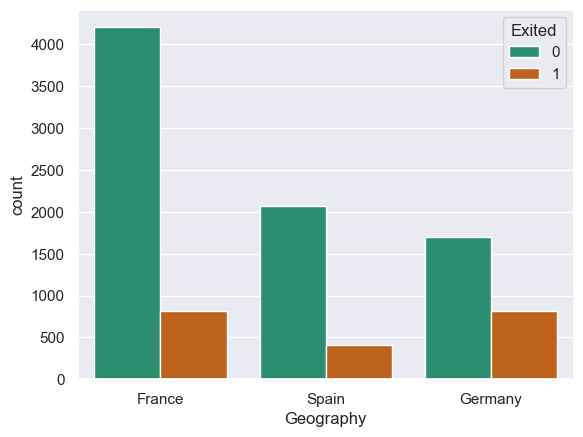

In [70]:
sns.countplot(x=data.Geography,hue=data.Exited)

<Axes: xlabel='Gender', ylabel='count'>

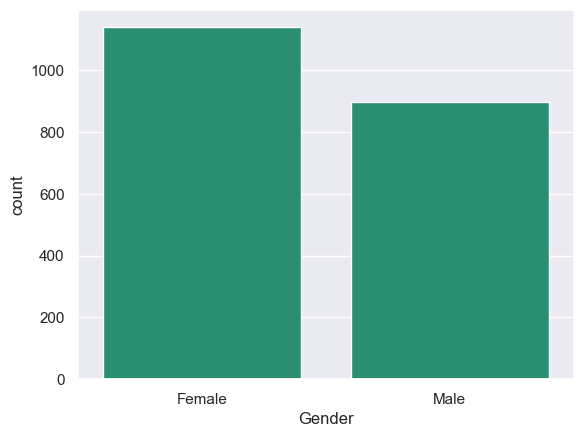

In [71]:
sns.countplot(x=data.Gender[data.Exited==1],legend=True)

In [72]:

# sns.swarmplot(x=data.Geography , y=data.Age , hue=data.Exited)

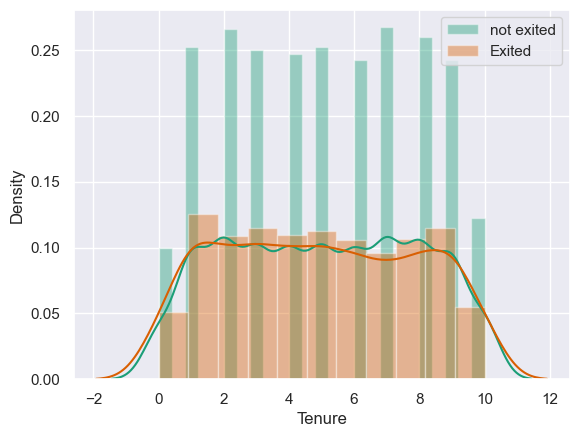

In [73]:
mask = data.Exited==1
sns.distplot(data.Tenure[mask==False] , label='not exited')
sns.distplot( data.Tenure[mask] , label='Exited')
plt.legend()

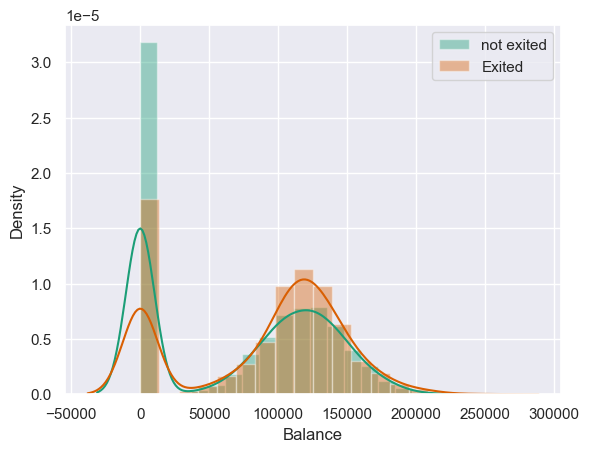

In [74]:
sns.distplot(data.Balance[data.Exited==0] , label='not exited')
sns.distplot( data.Balance[data.Exited==1] , label='Exited')
plt.legend()

<Axes: ylabel='Density'>

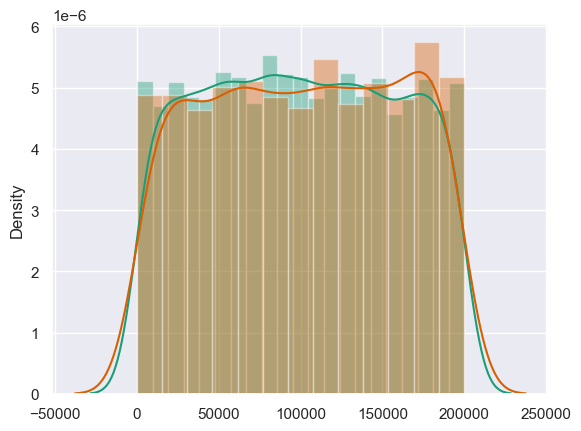

In [75]:
sns.distplot(x=data.EstimatedSalary[mask==False])
sns.distplot(x=data.EstimatedSalary[mask])

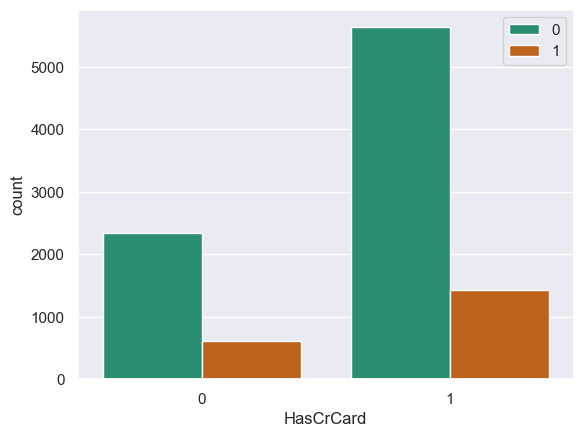

In [76]:
sns.countplot(x=data.HasCrCard , hue=data.Exited)
plt.legend()

In [77]:
data=data.drop(['RowNumber','CustomerId','Surname'] , axis=1)


# importing sk learn and ussing leverencoder 

In [78]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['Geography']=le.fit_transform(data.Geography)
le1=LabelEncoder()
data.Gender=le1.fit_transform(data.Gender)

In [79]:
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1


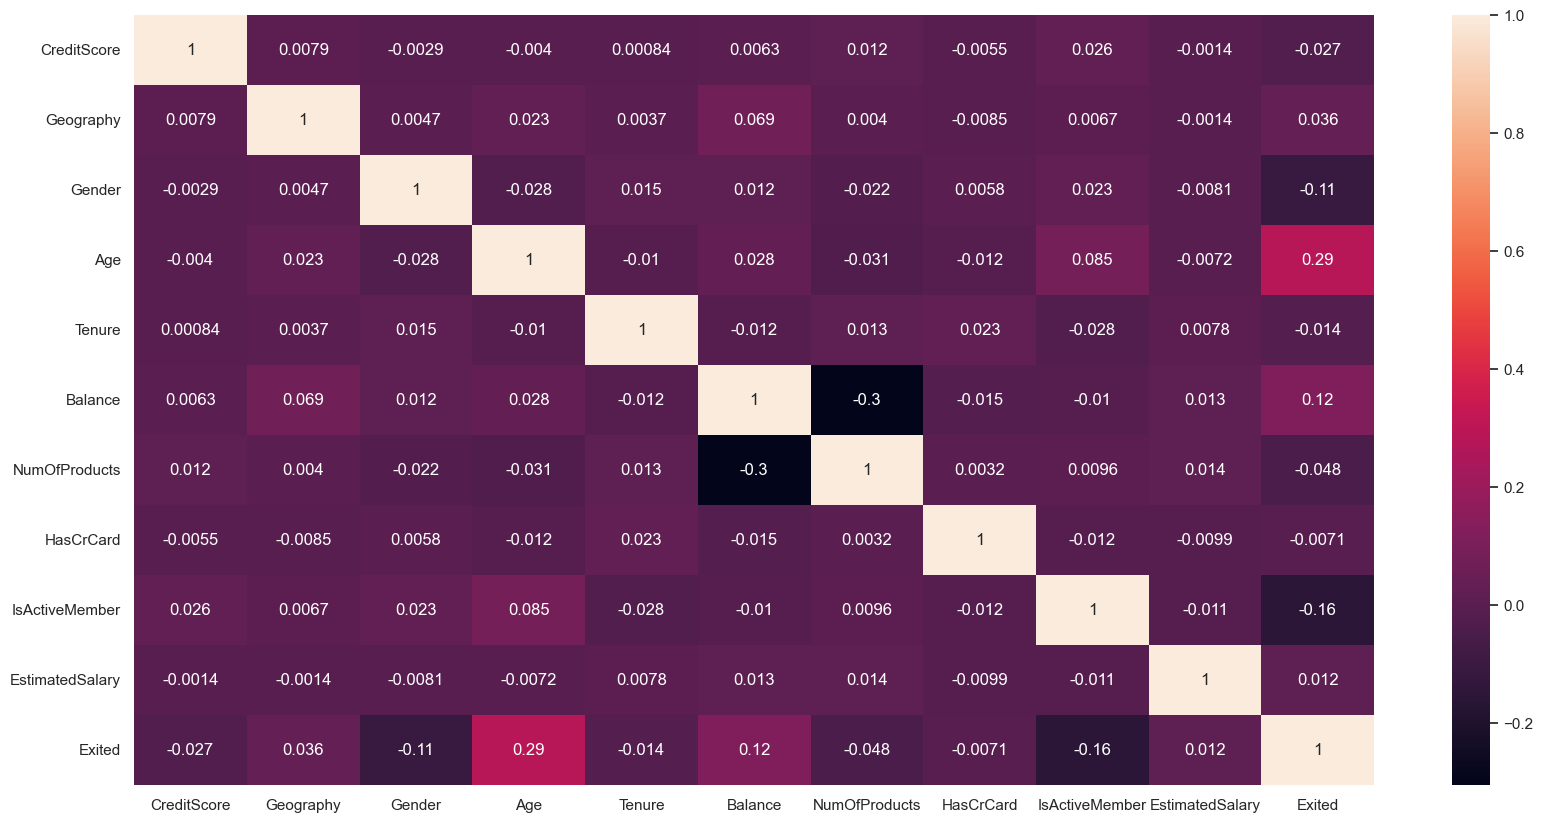

In [80]:
plt.figure(figsize=(20, 10)) 
sns.heatmap(data.corr(), annot=True)
plt.show()

In [81]:
print(data.dtypes)
inputs=data.drop(['Exited'],axis=1)
output=data.Exited

CreditScore          int64
Geography            int64
Gender               int64
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [82]:
from sklearn.linear_model import LogisticRegression
alg=LogisticRegression()
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(inputs,output)
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_test=sc.fit_transform(x_test)
x_train=sc.fit_transform(x_train)

alg.fit(x_train,y_train)
yp1=alg.predict(x_test)

In [83]:

from sklearn.metrics import  accuracy_score , precision_score , recall_score , f1_score
print(accuracy_score(y_test , yp1))
print(recall_score(y_test , yp1))
print(precision_score(y_test , yp1))
print(f1_score(y_test , yp1))

0.8072
0.16403162055335968
0.5845070422535211
0.25617283950617287


In [84]:
from sklearn.naive_bayes import GaussianNB
alg=GaussianNB()
alg.fit(x_train,y_train)
yp1=alg.predict(x_test)
from sklearn.metrics import  accuracy_score , precision_score , recall_score , f1_score
print(accuracy_score(y_test , yp1))
print(recall_score(y_test , yp1))
print(precision_score(y_test , yp1))
print(f1_score(y_test , yp1))

0.8252
0.21541501976284586
0.7315436241610739
0.332824427480916


In [85]:
from sklearn.neighbors import KNeighborsClassifier
alg=KNeighborsClassifier(n_neighbors=3)
alg.fit(x_train,y_train)
yp1=alg.predict(x_test)
from sklearn.metrics import  accuracy_score , precision_score , recall_score , f1_score
print(accuracy_score(y_test , yp1))
print(recall_score(y_test , yp1))
print(precision_score(y_test , yp1))
print(f1_score(y_test , yp1))

0.8212
0.391304347826087
0.5875370919881305
0.4697508896797153


In [86]:
from sklearn.tree import DecisionTreeClassifier
alg=DecisionTreeClassifier(criterion='entropy')
alg.fit(x_train,y_train)
yp1=alg.predict(x_test)
from sklearn.metrics import  accuracy_score , precision_score , recall_score , f1_score
print(accuracy_score(y_test , yp1))
print(recall_score(y_test , yp1))
print(precision_score(y_test , yp1))
print(f1_score(y_test , yp1))

0.7896
0.47035573122529645
0.4798387096774194
0.4750499001996008


In [87]:
from sklearn.ensemble import RandomForestClassifier
alg=RandomForestClassifier(criterion='entropy')
alg.fit(x_train,y_train)
yp1=alg.predict(x_test)
from sklearn.metrics import  accuracy_score , precision_score , recall_score , f1_score
print(accuracy_score(y_test , yp1))
print(recall_score(y_test , yp1))
print(precision_score(y_test , yp1))
print(f1_score(y_test , yp1))

0.8564
0.43873517786561267
0.7474747474747475
0.5529265255292652


In [88]:
from sklearn import svm
g=svm.SVC(kernel='rbf' , C=1000 , gamma=0.1)
g.fit(x_train , y_train)
yp1 = g.predict(x_test)
from sklearn.metrics import  accuracy_score , precision_score , recall_score , f1_score
print(accuracy_score(y_test , yp1))
print(recall_score(y_test , yp1))
print(precision_score(y_test , yp1))
print(f1_score(y_test , yp1))

0.7836
0.4624505928853755
0.46520874751491054
0.4638255698711596
